## Imports

In [1]:
# --- standard ---
import os
import sys
import time
from datetime import datetime
from pathlib import Path

# --- scientific ---
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LightSource
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import ndimage
from scipy.interpolate import RBFInterpolator
from scipy.spatial import cKDTree
import scipy.stats as stats

# --- machine learning / preprocessing ---
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- geostatistics ---
import skgstat as skg
from skgstat import models
import gstatsim as gs

# --- image / geometry utilities ---
from skimage.measure import find_contours

# --- parallelization ---
from joblib import Parallel, delayed

# --- local utilities (custom colormap) ---
from utils import geosoft_cmap_k65
geosoft_cmap = geosoft_cmap_k65()
ls = LightSource(azdeg=120, altdeg=45)

# --- local multigrid SGSIM implementation ---
from mgsim import mgsim, mgsim_nst
import sampling
import trendmaking
from variograms import cluster_variogram, build_variogram_dataframe
from synthetic import extract_flightlines


## Create synthetic flightline subset

Saved 2500 flightline points to ../demos/data/gt_synthetic.csv


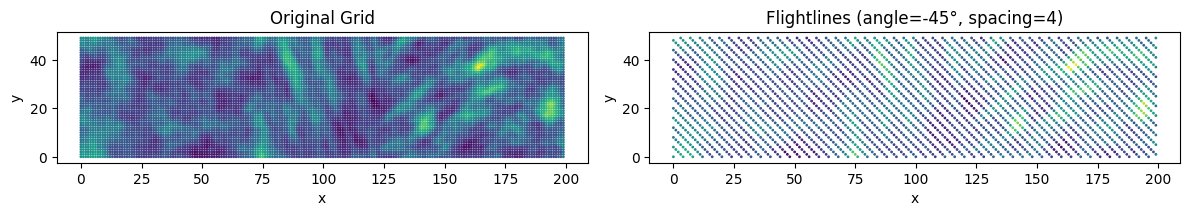

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from synthetic import extract_flightlines

# Load grid data
df = pd.read_csv('../demos/data/gt_xyvc.csv')

# Extract flightlines at 45°, spaced 10 cells apart
angle = -45
spacing = 4
sv_path = '../demos/data/gt_synthetic.csv'
fl = extract_flightlines(df, angle=angle, spacing=spacing, save_path=sv_path)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original grid
axes[0].scatter(df['x'], df['y'], c=df['val'], s=1, cmap='viridis')
axes[0].set_title('Original Grid')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_aspect('equal')

# Flightlines
axes[1].scatter(fl['x'], fl['y'], c=fl['val'], s=1, cmap='viridis')
axes[1].set_title(f'Flightlines (angle={angle}°, spacing={spacing})')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()


Dense: 2500 points, Sparse: 1250 points


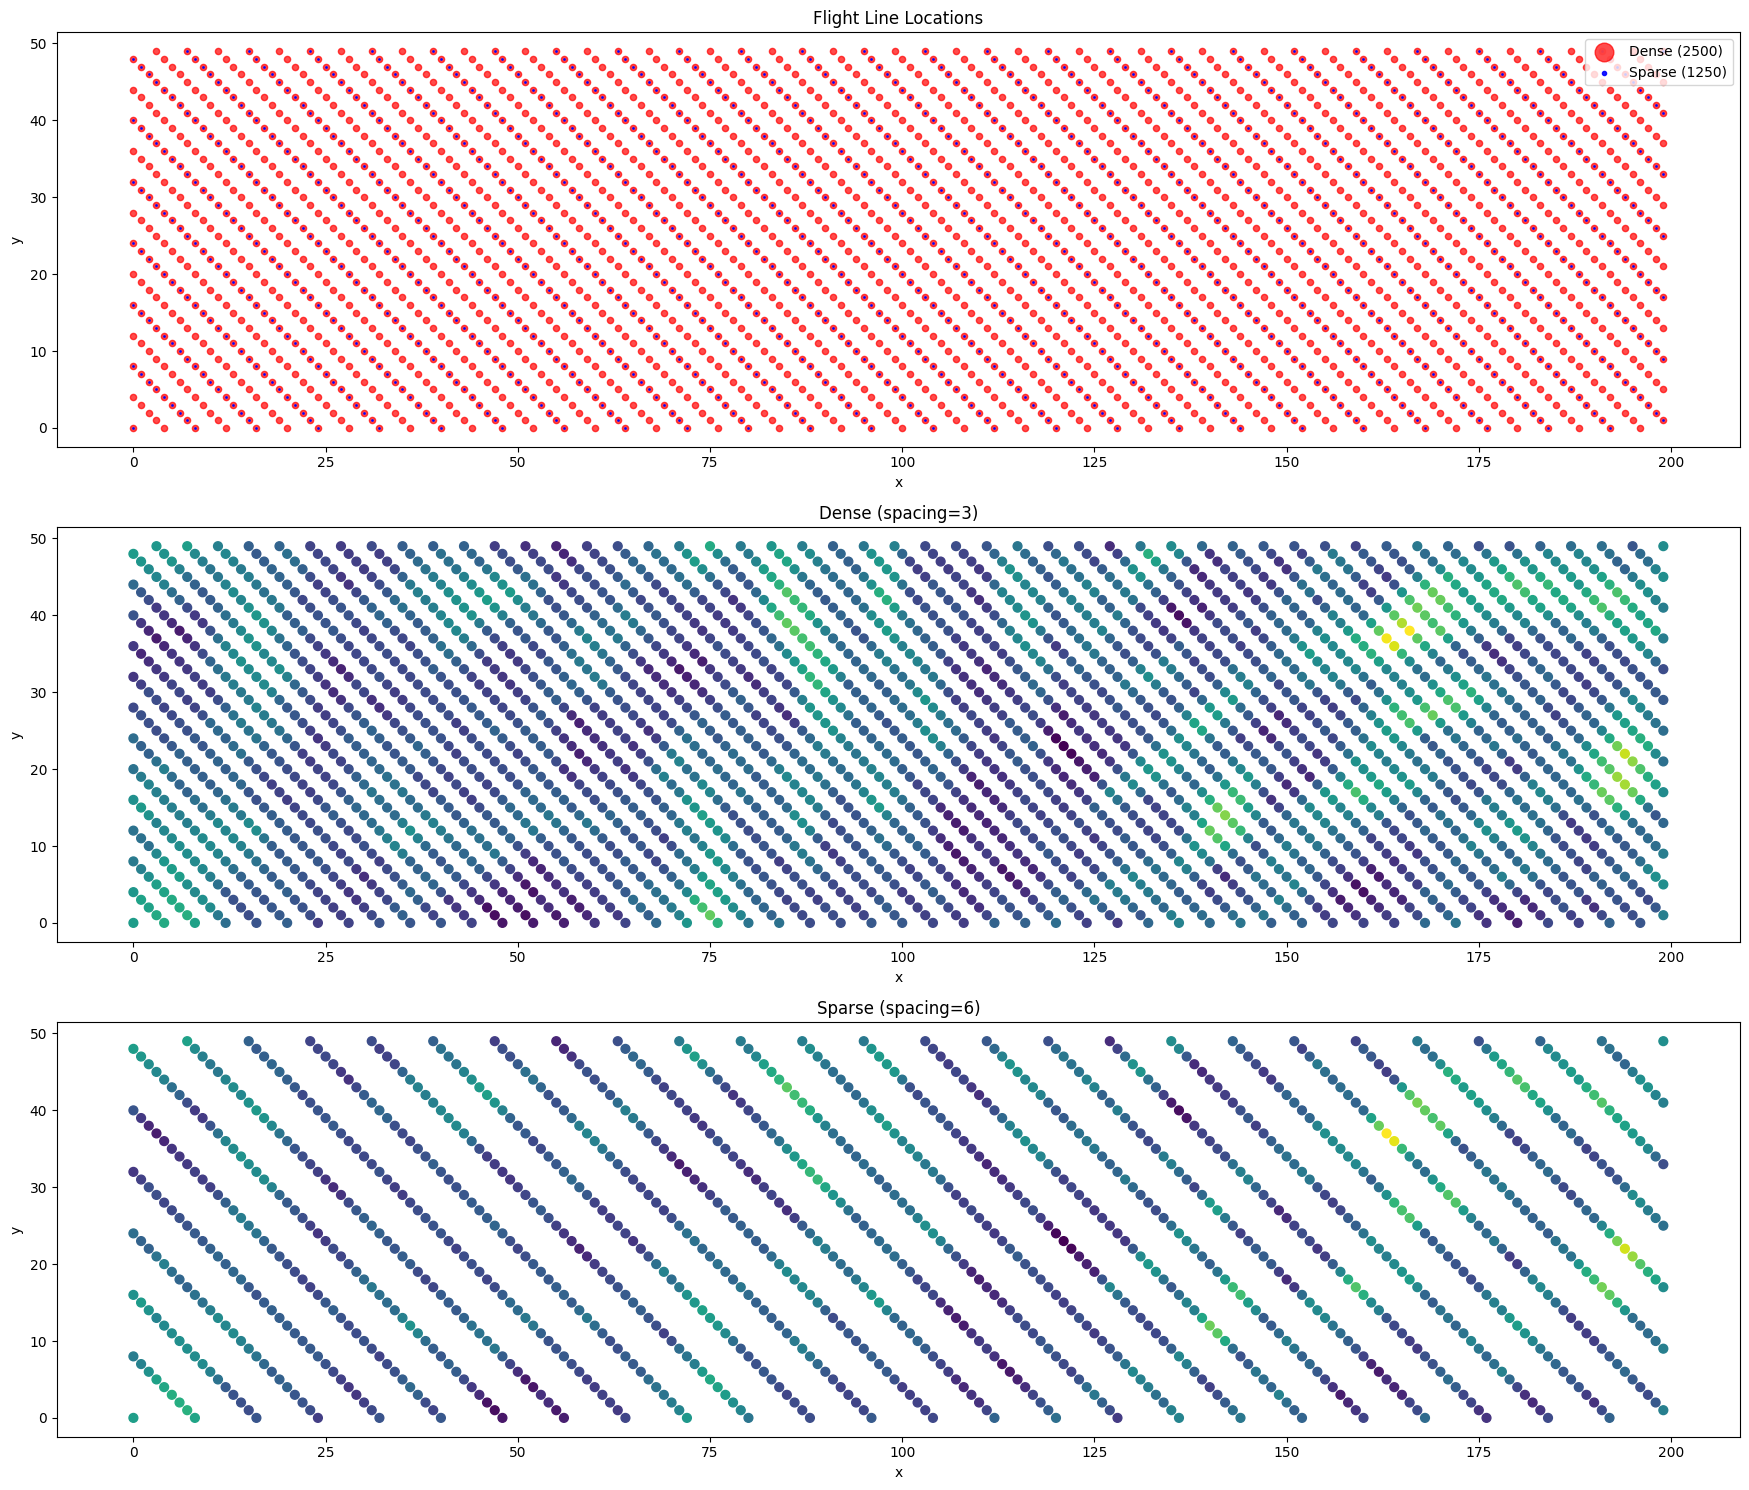

In [3]:
## VISUALIZE FLIGHT LINE DATASETS ##
## =============================== ##

import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
data_dir = '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/demos/data'
df_dense = pd.read_csv(f'{data_dir}/fl_xyvc_dense.csv')
df_sparse = pd.read_csv(f'{data_dir}/fl_xyvc_sparse.csv')

print(f"Dense: {len(df_dense)} points, Sparse: {len(df_sparse)} points")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(25, 15))

# Left: Overlapping locations
axes[0].scatter(df_dense['x'], df_dense['y'], c='red', s=20, alpha=0.7, label=f'Dense ({len(df_dense)})')
axes[0].scatter(df_sparse['x'], df_sparse['y'], c='blue', s=1, alpha=0.9, label=f'Sparse ({len(df_sparse)})')
axes[0].set_title('Flight Line Locations')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_aspect('equal')
axes[0].legend(markerscale=3)

# Middle: Dense colored by value
axes[1].scatter(df_dense['x'], df_dense['y'], c=df_dense['val'], s=40, cmap='viridis')
axes[1].set_title(f'Dense (spacing=3)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_aspect('equal')

# Right: Sparse colored by value
axes[2].scatter(df_sparse['x'], df_sparse['y'], c=df_sparse['val'], s=40, cmap='viridis')
axes[2].set_title(f'Sparse (spacing=6)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()


## Load and plot synthetic data

In [4]:
## LOAD SYNTHETIC GROUND TRUTH GRID AND FLIGHTLINES ##
## ================================================ ##

# GROUND TRUTH
df_gt_xyvc = pd.read_csv("../demos/data/gt_xyvc.csv")
gt_xyvc = df_gt_xyvc.values

# FLIGHT LINES
df_fl_xyvc = fl
fl_xyvc = df_fl_xyvc.values

# get number of subregions (clusters) from gt_xyvc
regions = gt_xyvc[:, 3]
unique_regions = np.unique(regions)
n_regions = len(unique_regions)
# set plot characteristics based on region clustering from gt_xyvc
cmap = plt.colormaps["tab20"].resampled(n_regions)
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(-0.5, n_regions+0.5, 1),
    ncolors=n_regions
)


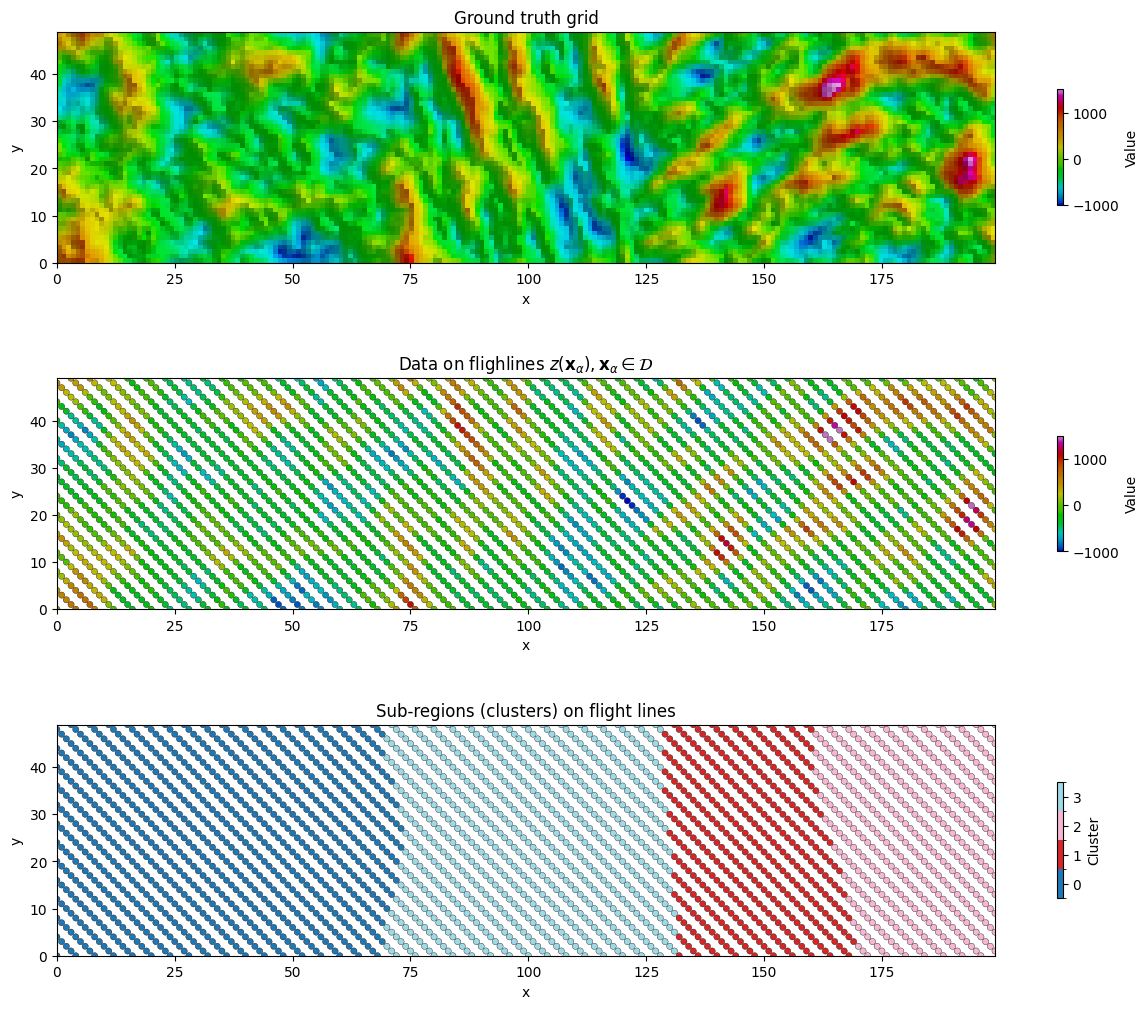

In [5]:
## PLOT GROUND TRUTH GRID AND FLIGHTLINES ##
## ====================================== ##

# color scale limits:
vmin, vmax = -1000, 1500
norm = Normalize(vmin=vmin, vmax=vmax)

# get grid dimensions:
x_unique = np.unique(gt_xyvc[:,0]); x_unique.sort()
y_unique = np.unique(gt_xyvc[:,1]); y_unique.sort()
nx, ny   = len(x_unique), len(y_unique)

# reshape to 2D grid:
gt_val_grid = gt_xyvc[:,2].reshape(ny, nx)

# light-shading:
gt_rgb = ls.shade(gt_val_grid, cmap=geosoft_cmap,blend_mode='soft', vmin=vmin, vmax=vmax)
extent = [x_unique.min(), x_unique.max(), y_unique.min(), y_unique.max()]

# cluster colormap setup ---
regions = gt_xyvc[:, 3]
unique_regions = np.unique(regions)
n_regions = len(unique_regions)
cmap_disc = plt.colormaps["tab20"].resampled(n_regions)
norm_disc = mpl.colors.BoundaryNorm(boundaries=np.arange(-0.5, n_regions + 0.5, 1),ncolors=n_regions)

# -- plots:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
plt.subplots_adjust(hspace=0.5)

# ground truth grid:
axes[0].imshow(gt_rgb, origin='lower', extent=extent, interpolation='nearest')
axes[0].set_title(r'Ground truth grid')
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
sm = plt.cm.ScalarMappable(norm=norm, cmap=geosoft_cmap)
sm.set_array([])
fig.colorbar(sm, ax=axes[0], shrink=0.5, label='Value')

# flight line data:
fl_x, fl_y, fl_val = fl_xyvc[:, 0], fl_xyvc[:, 1], fl_xyvc[:, 2]
sc = axes[1].scatter(fl_x, fl_y,c=fl_val, cmap=geosoft_cmap, norm=norm,s=20, edgecolors='k', linewidths=0.25,rasterized=True)
axes[1].set_title(r'Data on flighlines $z(\mathbf{x}_\alpha), \mathbf{x}_\alpha\in\mathcal{D}$')
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlim(extent[0], extent[1]); axes[1].set_ylim(extent[2], extent[3])
sm = plt.cm.ScalarMappable(norm=norm, cmap=geosoft_cmap)
sm.set_array([])
fig.colorbar(sm, ax=axes[1], shrink=0.5, label='Value')

# sub-region (clusters):
sc2 = axes[2].scatter(fl_xyvc[:, 0], fl_xyvc[:, 1],c=fl_xyvc[:, 3],cmap=cmap_disc, norm=norm_disc,s=20, edgecolors='k', linewidths=0.25, rasterized=True)
axes[2].set_title("Sub-regions (clusters) on flight lines")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
axes[2].set_aspect('equal', adjustable='box')
axes[2].set_xlim(extent[0], extent[1]); axes[2].set_ylim(extent[2], extent[3])
cb2 = fig.colorbar(sc2, ax=axes[2], shrink=0.5, ticks=np.arange(n_regions), label="Cluster")
cb2.ax.set_yticklabels([f"{int(r)}" for r in unique_regions])

plt.show()


## Make trend

In [6]:
## USE make_trend() TO MAKE A TREND ##
## ================================ ##

# define the grid and fl_xyvc
grid_xyc = np.column_stack([gt_xyvc[:, :2], gt_xyvc[:, 3]]) # isolate just the grid points and cluster id columns (get rid of values column)
fl_xyvc = fl_xyvc

# make the trend (note: this will be different trend each time the function is called, due to stochasticity in stratified sampling in the make_trend() function)
smoothing = 100.0
linespacing = 5
fl_xyvct, grid_xyct = trendmaking.make_trend(fl_xyvc, grid_xyc, smoothing, linespacing)


In [7]:
## COMPUTE RESIDUALS (only defined on flightlines) ##
## =============================================== ##

fl_resid   = fl_val - fl_xyvct[:,4]

# add residuals as new column of flightline array
fl_xyvctr = np.column_stack([fl_xyvct, fl_resid])


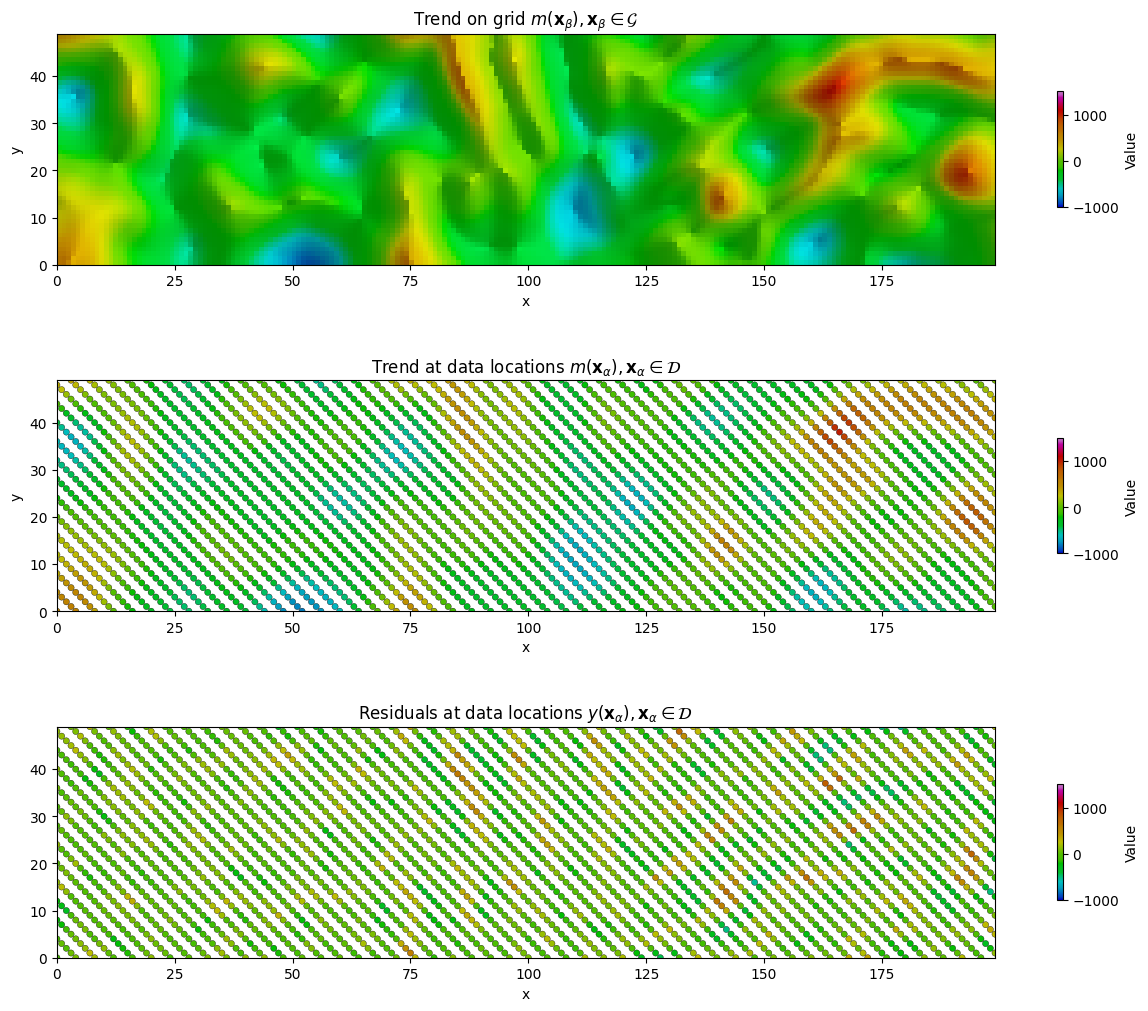

In [8]:
## PLOT TREND ##
## ========== ##

# color scale limits:
vmin, vmax = -1000, 1500
norm = Normalize(vmin=vmin, vmax=vmax)

# get grid dimensions:
x_unique = np.unique(grid_xyct[:,0]); x_unique.sort()
y_unique = np.unique(grid_xyct[:,1]); y_unique.sort()
nx, ny   = len(x_unique), len(y_unique)

# reshape to 2D grid:
trnd_val_grid = grid_xyct[:,3].reshape(ny, nx)

# light-shading:
trnd_rgb = ls.shade(trnd_val_grid, cmap=geosoft_cmap,blend_mode='soft', vmin=vmin, vmax=vmax)
extent = [x_unique.min(), x_unique.max(), y_unique.min(), y_unique.max()]

# -- plots:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
plt.subplots_adjust(hspace=0.5)

# trend on grid:
axes[0].imshow(trnd_rgb, origin='lower', extent=extent, interpolation='nearest')
axes[0].set_title(r'Trend on grid $m(\mathbf{x}_\beta), \mathbf{x}_\beta\in\mathcal{G}$')
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
sm = plt.cm.ScalarMappable(norm=norm, cmap=geosoft_cmap)
sm.set_array([])
fig.colorbar(sm, ax=axes[0], shrink=0.5, label='Value')

# trend on flight line locations:
fl_x, fl_y, fl_trnd = fl_xyvc[:, 0], fl_xyvc[:, 1], fl_xyvct[:, 4]
sc = axes[1].scatter(fl_x, fl_y,c=fl_trnd, cmap=geosoft_cmap, norm=norm,s=20, edgecolors='k', linewidths=0.25,rasterized=True)
axes[1].set_title(r'Trend at data locations $m(\mathbf{x}_\alpha), \mathbf{x}_\alpha\in\mathcal{D}$')
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlim(extent[0], extent[1])
axes[1].set_ylim(extent[2], extent[3])
sm = plt.cm.ScalarMappable(norm=norm, cmap=geosoft_cmap)
sm.set_array([])
fig.colorbar(sm, ax=axes[1], shrink=0.5, label='Value')

# residuals on flight line locations:
sc = axes[2].scatter(fl_x, fl_y,c=fl_resid, cmap=geosoft_cmap, norm=norm,s=20, edgecolors='k', linewidths=0.25,rasterized=True)
axes[2].set_title(r'Residuals at data locations $y(\mathbf{x}_\alpha), \mathbf{x}_\alpha\in\mathcal{D}$')
axes[2].set_xlabel("x"); axes[1].set_ylabel("y")
axes[2].set_aspect('equal', adjustable='box')
axes[2].set_xlim(extent[0], extent[1])
axes[2].set_ylim(extent[2], extent[3])
sm = plt.cm.ScalarMappable(norm=norm, cmap=geosoft_cmap)
sm.set_array([])
fig.colorbar(sm, ax=axes[2], shrink=0.5, label='Value')



## Create DataFrame for flightline information

In [9]:
## PACK FLIGHTLINE INFO AND GRID INFO INTO ##
##  DATAFRAMES FOR GStatSim COMPATIBILITY  ##
## ======================================= ##

df_fl_xyvctr = pd.DataFrame(
    fl_xyvctr,
    columns=["x", "y", "value", "cluster", "trend", "residual"]
)

df_grid_xyct = pd.DataFrame(
    grid_xyct,
    columns=["x", "y", "cluster", "trend"]
)

print("flightline DataFrame")
print(df_fl_xyvctr.head())
print("\ngrid DataFrame")
print(df_grid_xyct.head())


flightline DataFrame
      x    y       value  cluster       trend    residual
0   0.0  0.0  474.224075      0.0  551.052851  -76.828776
1   4.0  0.0  634.226889      0.0  551.593060   82.633829
2   8.0  0.0  543.684405      0.0  359.064265  184.620140
3  12.0  0.0  -36.874397      0.0    6.396891  -43.271288
4  16.0  0.0 -295.860241      0.0 -218.076171  -77.784070

grid DataFrame
     x    y  cluster       trend
0  0.0  0.0      0.0  551.052851
1  1.0  0.0      0.0  559.828446
2  2.0  0.0      0.0  565.408634
3  3.0  0.0      0.0  563.816369
4  4.0  0.0      0.0  551.593060


In [10]:
## AUGMENT DATAFRAME TO INCLUDE OBSERVATION POINT SET INFORMATION ##
## ============================================================== ##

# config
xcol, ycol, vcol = "x", "y", "value"
tol = 1e-8

# build KDTree to map flightline points -> grid nodes
grid_xy = df_grid_xyct[[xcol, ycol]].to_numpy()
obs_xy  = df_fl_xyvctr[[xcol, ycol]].to_numpy()
obs_val = df_fl_xyvctr[vcol].to_numpy()

tree = cKDTree(grid_xy)
dist, gi = tree.query(obs_xy, distance_upper_bound=tol)  # gi==len(grid_xy) if no match
valid = np.isfinite(dist) & (gi >= 0) & (gi < len(grid_xy))

# start from grid; create df_xyvtcs with desired columns and dtypes
df_xyvtcs = df_grid_xyct.copy()
df_xyvtcs["set"] = np.zeros(len(df_xyvtcs), dtype=np.int8)

# initialize non-observation points as NaN
df_xyvtcs[vcol] = np.nan

# handle duplicates
matched = pd.DataFrame({"grid_idx": gi[valid].astype(int), vcol: obs_val[valid]})
agg = matched.groupby("grid_idx", as_index=False)[vcol].mean()

# assign values and flags
df_xyvtcs.loc[agg["grid_idx"].values, vcol] = agg[vcol].values
df_xyvtcs.loc[agg["grid_idx"].values, "set"] = 1

# reorder columns: x, y, value, trend, cluster, set
first = [xcol, ycol, vcol, "trend", "cluster", "set"]
rest = [c for c in df_xyvtcs.columns if c not in first]
df_xyvtcs = df_xyvtcs.loc[:, first + rest]

# print statements
print(f"Obs points total: {len(obs_xy)}")
print(f"Matched to grid within tol: {valid.sum()}")
print(f"Grid nodes updated (deduped): {len(agg)}")
print(f"Unmatched obs: {len(obs_xy) - valid.sum()}")

df_xyvtcs


Obs points total: 2500
Matched to grid within tol: 2500
Grid nodes updated (deduped): 2500
Unmatched obs: 0


,x,y,value,trend,cluster,set
0,0.0,0.0,474.224075,551.052851,0.0,1
1,1.0,0.0,NaN,559.828446,0.0,0
2,2.0,0.0,NaN,565.408634,0.0,0
3,3.0,0.0,NaN,563.816369,0.0,0
4,4.0,0.0,634.226889,551.593060,0.0,1
...,...,...,...,...,...,...
9995,195.0,49.0,-274.330593,-9.845115,2.0,1
9996,196.0,49.0,NaN,6.702370,2.0,0
9997,197.0,49.0,NaN,33.460536,2.0,0
9998,198.0,49.0,NaN,63.141371,2.0,0


In [11]:
df_singlecluster = df_xyvtcs.copy()
df_singlecluster["cluster"] = 0
df_singlecluster

,x,y,value,trend,cluster,set
0,0.0,0.0,474.224075,551.052851,0,1
1,1.0,0.0,NaN,559.828446,0,0
2,2.0,0.0,NaN,565.408634,0,0
3,3.0,0.0,NaN,563.816369,0,0
4,4.0,0.0,634.226889,551.593060,0,1
...,...,...,...,...,...,...
9995,195.0,49.0,-274.330593,-9.845115,0,1
9996,196.0,49.0,NaN,6.702370,0,0
9997,197.0,49.0,NaN,33.460536,0,0
9998,198.0,49.0,NaN,63.141371,0,0


## Check out the Gaussian-ness of the residuals

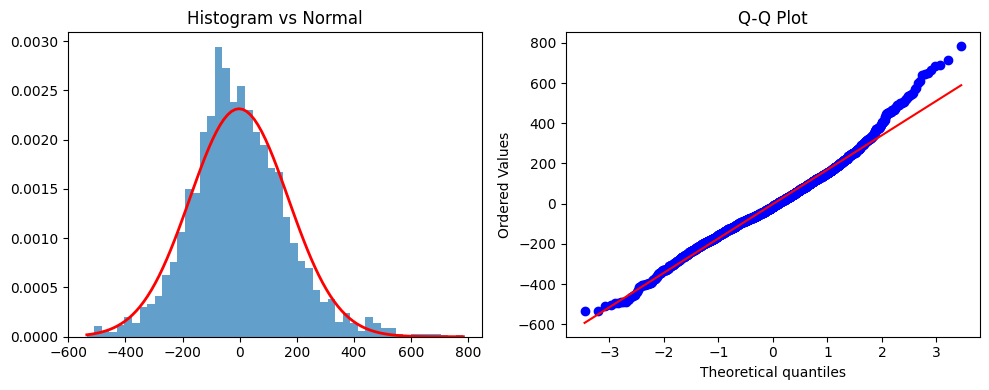

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram with normal curve overlay
ax1 = axes[0]
ax1.hist(df_fl_xyvctr['residual'], bins=50, density=True, alpha=0.7)
x = np.linspace(df_fl_xyvctr['residual'].min(), df_fl_xyvctr['residual'].max(), 100)
ax1.plot(x, stats.norm.pdf(x, df_fl_xyvctr['residual'].mean(), df_fl_xyvctr['residual'].std()), 'r-', lw=2)
ax1.set_title('Histogram vs Normal')

# Q-Q plot
ax2 = axes[1]
stats.probplot(df_fl_xyvctr['residual'], dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot')

plt.tight_layout()


In [13]:
from scipy.stats import shapiro, normaltest, skew, kurtosis

residuals = df_fl_xyvctr['residual'].values

# Skewness and kurtosis (quick check)
print(f"Skewness: {skew(residuals):.3f}")  # close to 0 is good
print(f"Kurtosis: {kurtosis(residuals):.3f}")  # close to 0 is good

# D'Agostino-Pearson test (works for larger samples)
stat, p = normaltest(residuals)
print(f"Normality test p-value: {p:.4f}")


Skewness: 0.441
Kurtosis: 1.140
Normality test p-value: 0.0000


## Explore variograms

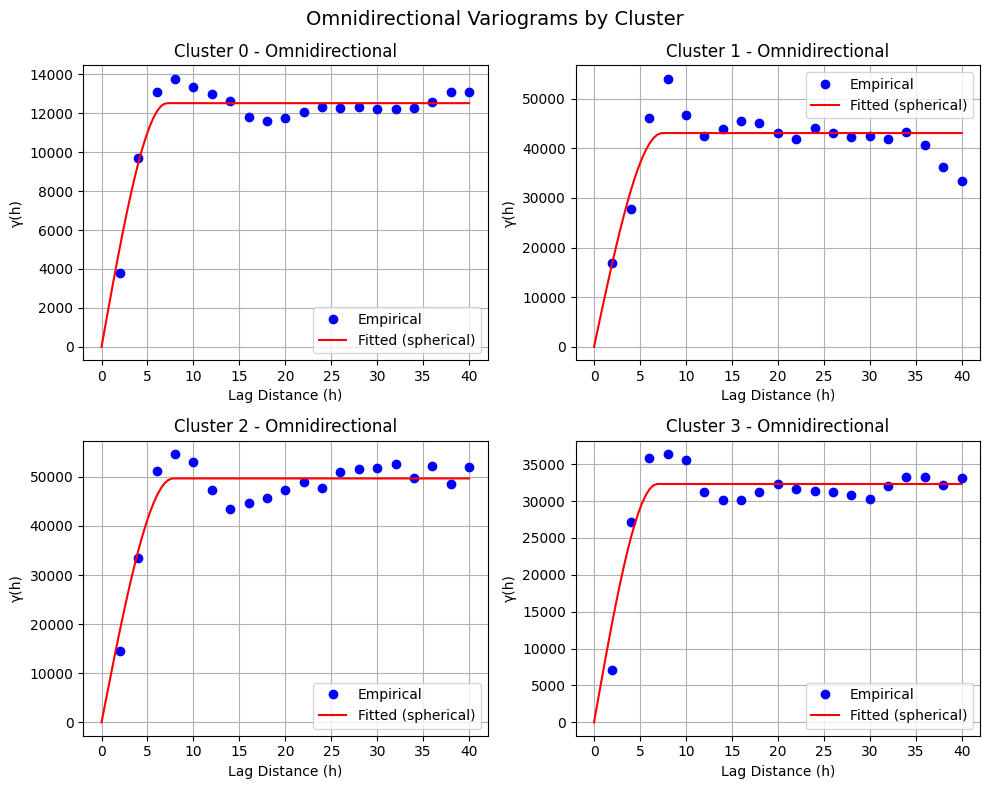


Fitted Parameters (omnidirectional):
--------------------------------------------------
Cluster    Range        Sill         Nugget      
--------------------------------------------------
0          7.12         12520.9616   0.0000      
1          7.42         43078.6346   0.0000      
2          7.77         49683.8993   0.0000      
3          6.89         32314.9092   0.0000      

Cluster 0 - Directional Variograms
Azimuth    Range        Sill         Nugget      
----------------------------------------------
0°         6.53         12522.1298   0.0000      
45°         7.31         12455.4621   0.0000      
90°         6.32         12765.8883   0.0000      
135°         6.64         12276.5681   0.0000      

Anisotropy: max range=7.3 at 45°, min=6.3 at 90°, ratio=1.16

Cluster 1 - Directional Variograms
Azimuth    Range        Sill         Nugget      
----------------------------------------------
0°         7.46         42986.7727   0.0000      
45°         5.77         429

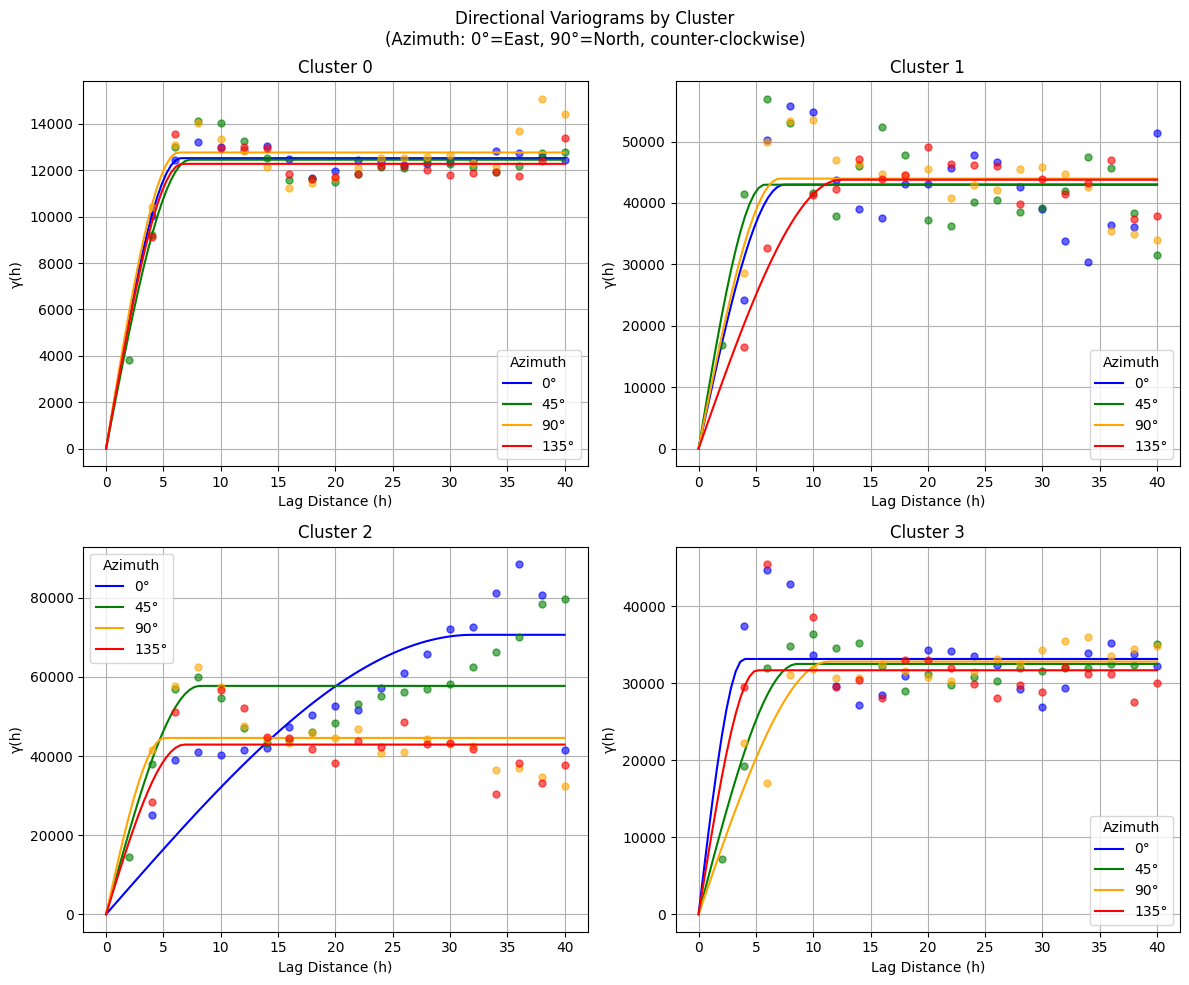

In [20]:
## VARIOGRAM EXPLORATION ##
## ===================== ##

# Note on azimuth convention:
# - Azimuth is measured in degrees from East (positive x-axis)
# - 0° = East, 90° = North, 180° = West, 270° = South
# - Rotation is counter-clockwise from the positive x-axis

# --- Settings ---
maxlag = 40
n_lags = 20
model = 'spherical'  # options: 'spherical', 'exponential', 'gaussian'
value_col = 'residual'  # or 'residual' for non-transformed
azimuths = [0, 45, 90, 135]  # directions to check for anisotropy
bandwidth = 45  # angular tolerance (degrees)

# --- 1. Omnidirectional variograms (all clusters in one figure) ---
V0 = cluster_variogram(df_fl_xyvctr, value_col, 0, maxlag, n_lags, model)
V1 = cluster_variogram(df_fl_xyvctr, value_col, 1, maxlag, n_lags, model)
V2 = cluster_variogram(df_fl_xyvctr, value_col, 2, maxlag, n_lags, model)
V3 = cluster_variogram(df_fl_xyvctr, value_col, 3, maxlag, n_lags, model)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

for i, V in enumerate([V0, V1, V2, V3]):
    axs[i].plot(V.bins, V.experimental, 'o', color='blue', label='Empirical')
    x_model = np.linspace(0, V.bins[-1], 100)
    y_model = V.transform(x_model)
    axs[i].plot(x_model, y_model, '-', color='red', label=f'Fitted ({model})')
    axs[i].set_xlabel('Lag Distance (h)')
    axs[i].set_ylabel('γ(h)')
    axs[i].set_title(f'Cluster {i} - Omnidirectional')
    axs[i].legend()
    axs[i].grid(True)

plt.suptitle('Omnidirectional Variograms by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

# Print fitted parameters
print("\nFitted Parameters (omnidirectional):")
print("-" * 50)
print(f"{'Cluster':<10} {'Range':<12} {'Sill':<12} {'Nugget':<12}")
print("-" * 50)
for i, V in enumerate([V0, V1, V2, V3]):
    r, s, n = V.parameters
    print(f"{i:<10} {r:<12.2f} {s:<12.4f} {n:<12.4f}")


# --- 2. Directional variograms (all azimuths on same plot, per cluster) ---
colors_az = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'pink', 'gray']

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for cluster_idx in range(4):
    ax = axs[cluster_idx]
    
    print(f"\n{'='*50}")
    print(f"Cluster {cluster_idx} - Directional Variograms")
    print(f"{'='*50}")
    print(f"{'Azimuth':<10} {'Range':<12} {'Sill':<12} {'Nugget':<12}")
    print("-" * 46)
    
    for j, az in enumerate(azimuths):
        V = cluster_variogram(
            df_fl_xyvctr, value_col, cluster_idx,
            maxlag, n_lags, model,
            azimuth=az, bandwidth=bandwidth
        )
        
        # Plot empirical points
        ax.plot(V.bins, V.experimental, 'o', color=colors_az[j], alpha=0.6, markersize=5)
        
        # Plot fitted model
        x_model = np.linspace(0, V.bins[-1], 100)
        y_model = V.transform(x_model)
        ax.plot(x_model, y_model, '-', color=colors_az[j], label=f'{az}°')
        
        # Print parameters
        r, s, n = V.parameters
        print(f"{az}°{'':<8} {r:<12.2f} {s:<12.4f} {n:<12.4f}")
    
    ax.set_xlabel('Lag Distance (h)')
    ax.set_ylabel('γ(h)')
    ax.set_title(f'Cluster {cluster_idx}')
    ax.legend(title='Azimuth')
    ax.grid(True)
    
    # Compute anisotropy summary
    ranges = []
    for az in azimuths:
        V = cluster_variogram(df_fl_xyvctr, value_col, cluster_idx, maxlag, n_lags, model, azimuth=az, bandwidth=bandwidth)
        ranges.append((az, V.parameters[0]))
    
    max_az, max_range = max(ranges, key=lambda x: x[1])
    min_az, min_range = min(ranges, key=lambda x: x[1])
    ratio = max_range / min_range if min_range > 0 else float('inf')
    
    print(f"\nAnisotropy: max range={max_range:.1f} at {max_az}°, min={min_range:.1f} at {min_az}°, ratio={ratio:.2f}")

plt.suptitle('Directional Variograms by Cluster\n(Azimuth: 0°=East, 90°=North, counter-clockwise)', fontsize=12)
plt.tight_layout()
plt.show()


## User to define variograms per cluster here

In [21]:
## BUILD VARIOGRAM PARAMETERS FOR KRIGING ##
## ====================================== ##

# --- User Settings ---
use_anisotropic = False  # Set to True if you detected significant anisotropy
model = 'spherical'  # 'spherical', 'exponential', or 'gaussian'

# --- Re-fit omnidirectional variograms with chosen model ---
V0 = cluster_variogram(df_fl_xyvctr, 'residual', 0, maxlag, n_lags, model)
V1 = cluster_variogram(df_fl_xyvctr, 'residual', 1, maxlag, n_lags, model)
V2 = cluster_variogram(df_fl_xyvctr, 'residual', 2, maxlag, n_lags, model)
V3 = cluster_variogram(df_fl_xyvctr, 'residual', 3, maxlag, n_lags, model)
variograms = [V0, V1, V2, V3]

if not use_anisotropic:
    # =====================
    # ISOTROPIC VARIOGRAMS
    # =====================
    df_gamma = build_variogram_dataframe(variograms)
    
    print("Using ISOTROPIC variogram parameters:")
    print("-" * 60)
    print(f"{'Cluster':<10} {'Range':<12} {'Sill':<12} {'Nugget':<12}")
    print("-" * 60)
    for i, V in enumerate(variograms):
        r, s, n = V.parameters
        print(f"{i:<10} {r:<12.2f} {s:<12.4f} {n:<12.4f}")

else:
    # =======================
    # ANISOTROPIC VARIOGRAMS
    # =======================
    # Specify per-cluster anisotropy parameters based on directional analysis
    
    # Azimuths per cluster (direction of MAXIMUM correlation)
    # Set based on which direction showed longest range in directional variograms
    aniso_azimuths = [
        0,    # Cluster 0: max correlation along E-W
        45,   # Cluster 1: max correlation along NE-SW
        0,    # Cluster 2: max correlation along E-W
        135,   # Cluster 3: max correlation along N-S
    ]
    
    # Minor ranges per cluster (range perpendicular to azimuth)
    # Option A: As fraction of major range
    minor_ranges = [
        V0.parameters[0] * 0.6,  # Cluster 0
        V1.parameters[0] * 0.5,  # Cluster 1
        V2.parameters[0] * 0.7,  # Cluster 2
        V3.parameters[0] * 0.6,  # Cluster 3
    ]
    # Option B: Explicit values (uncomment and edit):
    # minor_ranges = [8.0, 6.0, 10.0, 7.5]
    
    df_gamma = build_variogram_dataframe(
        variograms,
        azimuths=aniso_azimuths,
        minor_ranges=minor_ranges
    )
    
    print("Using ANISOTROPIC variogram parameters:")
    print("-" * 80)
    print(f"{'Cluster':<10} {'Azimuth':<10} {'Major Range':<14} {'Minor Range':<14} {'Sill':<12} {'Nugget':<12}")
    print("-" * 80)
    for i, V in enumerate(variograms):
        r, s, n = V.parameters
        print(f"{i:<10} {aniso_azimuths[i]:<10}° {r:<14.2f} {minor_ranges[i]:<14.2f} {s:<12.4f} {n:<12.4f}")

# --- Display final df_gamma ---
print("\n" + "=" * 60)
print("Final variogram DataFrame for MGSIM:")
print("=" * 60)
df_gamma


Using ISOTROPIC variogram parameters:
------------------------------------------------------------
Cluster    Range        Sill         Nugget      
------------------------------------------------------------
0          7.12         12520.9616   0.0000      
1          7.42         43078.6346   0.0000      
2          7.77         49683.8993   0.0000      
3          6.89         32314.9092   0.0000      

Final variogram DataFrame for MGSIM:


,Variogram
0,"[0.0, 0, 7.122916733416807, 7.122916733416807,..."
1,"[0.0, 0, 7.416052384872075, 7.416052384872075,..."
2,"[0.0, 0, 7.7708028915805025, 7.770802891580502..."
3,"[0.0, 0, 6.889866679115066, 6.889866679115066,..."


## Run MGSIM to generate one realization

In [22]:
## GENERATE ONE REALIZATION WITH MGSIM ##
## =================================== ##

mg_resols = [20,10,5,4,3,2,1]  # note: spacing is in grid units (pixels) for this demo
df_grid = df_xyvtcs
df_mgsim = mgsim(mg_resols, df_grid, df_gamma, xx='x', yy='y', zz='residual', kk='cluster', num_points=10, radius=40)


MultiGrid iteration 1: Processing resolution 20


100%|██████████| 10000/10000 [01:24<00:00, 118.97it/s]


MultiGrid iteration 2: Processing resolution 10


100%|██████████| 10000/10000 [01:20<00:00, 124.26it/s]


MultiGrid iteration 3: Processing resolution 5


...

100%|██████████| 10000/10000 [01:14<00:00, 134.96it/s]


MultiGrid iteration 6: Processing resolution 2


100%|██████████| 10000/10000 [01:04<00:00, 154.67it/s]


MultiGrid iteration 7: Processing resolution 1


100%|██████████| 10000/10000 [00:50<00:00, 197.63it/s]


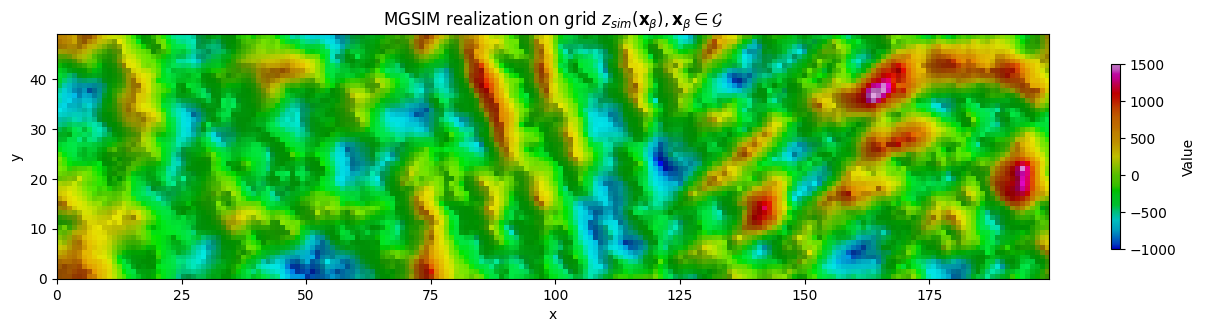

In [23]:
## PLOT MGSIM REALIZATION ##
## ====================== ##

# color scale limits:
vmin, vmax = -1000, 1500
norm = Normalize(vmin=vmin, vmax=vmax)

# get grid dimensions:
x_coords = df_mgsim['x'].values
y_coords = df_mgsim['y'].values
x_unique = np.unique(x_coords)
y_unique = np.unique(y_coords)
nx, ny   = len(x_unique), len(y_unique)

# values of mgsim realization:
values = df_mgsim['newtrend'].values

# reshape to 2D grid:
mgsim_realization = values.reshape(ny, nx)

# light-shading:
mgreal_rgb = ls.shade(mgsim_realization, cmap=geosoft_cmap,
                      blend_mode='soft', vmin=vmin, vmax=vmax)
extent = [x_unique.min(), x_unique.max(), y_unique.min(), y_unique.max()]

# plot
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.imshow(mgreal_rgb, origin='lower', extent=extent, interpolation='nearest')
ax.set_title(r'MGSIM realization on grid $z_{sim}(\mathbf{x}_\beta), \mathbf{x}_\beta\in\mathcal{G}$')
ax.set_xlabel("x"); ax.set_ylabel("y")
sm = plt.cm.ScalarMappable(norm=norm, cmap=geosoft_cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.3, label='Value')


## Standard geostats

In [24]:
## KRIGING ##
## ======= ##

# normal score transformation
data = df_fl_xyvctr['residual'].values.reshape(-1, 1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(data)
df_fl_xyvctr['nval'] = nst_trans.transform(data)

# compute experimental (isotropic) variogram
coords = df_fl_xyvctr[['x', 'y']].values
values = df_fl_xyvctr['nval']

maxlag = 40
n_lags = 40

V1 = skg.Variogram(coords, values, bin_func='even', n_lags=n_lags,
                    maxlag=maxlag, normalize=False)
V1.model = 'spherical'

print(f"Variogram parameters: range={V1.parameters[0]:.2f}, sill={V1.parameters[1]:.4f}, nugget={V1.parameters[2]:.4f}")

# define coordinate grid
xmin = np.min(df_fl_xyvctr['x']); xmax = np.max(df_fl_xyvctr['x'])
ymin = np.min(df_fl_xyvctr['y']); ymax = np.max(df_fl_xyvctr['y'])
extent = [xmin, xmax, ymin, ymax]

res = 1
Pred_grid_xy = gs.Gridding.prediction_grid(xmin, xmax, ymin, ymax, res)

# set variogram parameters
azimuth = 0
nugget = V1.parameters[2]
major_range = V1.parameters[0]
minor_range = V1.parameters[0]
sill = V1.parameters[1]
vtype = 'Spherical'

vario = [azimuth, nugget, major_range, minor_range, sill, vtype]

k = 10
rad = 40

# simple kriging
est_SK, var_SK = gs.Interpolation.skrige(Pred_grid_xy, df_fl_xyvctr, 'x', 'y', 'nval', k, vario, rad)

# reverse normal score transformation
var_SK[var_SK < 0] = 0
std_SK = np.sqrt(var_SK)

est = est_SK.reshape(-1, 1)
std = std_SK.reshape(-1, 1)

spred_trans = nst_trans.inverse_transform(est)
sstd_trans = nst_trans.inverse_transform(std)
sstd_trans = sstd_trans - np.min(sstd_trans)


Variogram parameters: range=6.50, sill=1.0362, nugget=0.0000


100%|██████████| 10000/10000 [00:44<00:00, 224.59it/s]


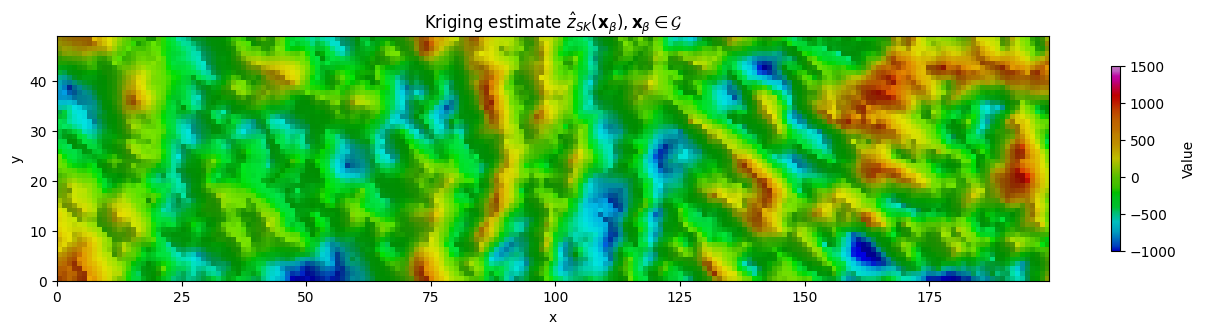

In [26]:
## PLOT KRIGING RESULT ##
## =================== ##

# color scale limits:
vmin, vmax = -1000, 1500
norm = Normalize(vmin=vmin, vmax=vmax)

# get grid dimensions from the grid DataFrame:
x_unique = np.sort(df_grid_xyct['x'].unique())
y_unique = np.sort(df_grid_xyct['y'].unique())
nx, ny = len(x_unique), len(y_unique)
extent = [x_unique.min(), x_unique.max(), y_unique.min(), y_unique.max()]

# kriging estimate = back-transformed residual + trend
kriging_result = spred_trans.flatten() + df_grid_xyct['trend'].values

# reshape to 2D grid:
kriging_grid = kriging_result.reshape(ny, nx)

# light-shading:
krig_rgb = ls.shade(kriging_grid, cmap=geosoft_cmap,
                    blend_mode='soft', vmin=vmin, vmax=vmax)

# plot
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.imshow(krig_rgb, origin='lower', extent=extent, interpolation='nearest')
ax.set_title(r'Kriging estimate $\hat{z}_{SK}(\mathbf{x}_\beta), \mathbf{x}_\beta\in\mathcal{G}$')
ax.set_xlabel("x"); ax.set_ylabel("y")
sm = plt.cm.ScalarMappable(norm=norm, cmap=geosoft_cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.3, label='Value')


## Generate (50) realizations

In [38]:
## GENERATE 50 REALIZATIONS WITH MGSIM ##
## ==================================== ##

import numpy as np

mg_resols = [20,10,5,4,3,2,1]
df_grid = df_xyvtcs
n_realizations = 50

# Store all realizations
realizations = []

for i in range(n_realizations):
    print(f"Realization {i+1}/{n_realizations}")
    df_mgsim = mgsim(mg_resols, df_grid, df_gamma, xx='x', yy='y', zz='residual', 
                     kk='cluster', num_points=10, radius=40)
    realizations.append(df_mgsim['newtrend'].values)

# Stack into array (n_realizations x n_points)
realizations = np.array(realizations)

# Compute mean and variance
mean_field = np.mean(realizations, axis=0)
var_field = np.var(realizations, axis=0)

print(f"Done! Generated {n_realizations} realizations.")


Realization 1/50
MultiGrid iteration 1: Processing resolution 20


100%|██████████| 10000/10000 [00:38<00:00, 261.82it/s]


MultiGrid iteration 2: Processing resolution 10


100%|██████████| 10000/10000 [00:37<00:00, 266.39it/s]


MultiGrid iteration 3: Processing resolution 5


...

MultiGrid iteration 6: Processing resolution 2


100%|██████████| 10000/10000 [00:27<00:00, 363.06it/s]


MultiGrid iteration 7: Processing resolution 1


100%|██████████| 10000/10000 [00:27<00:00, 367.02it/s]

Done! Generated 50 realizations.


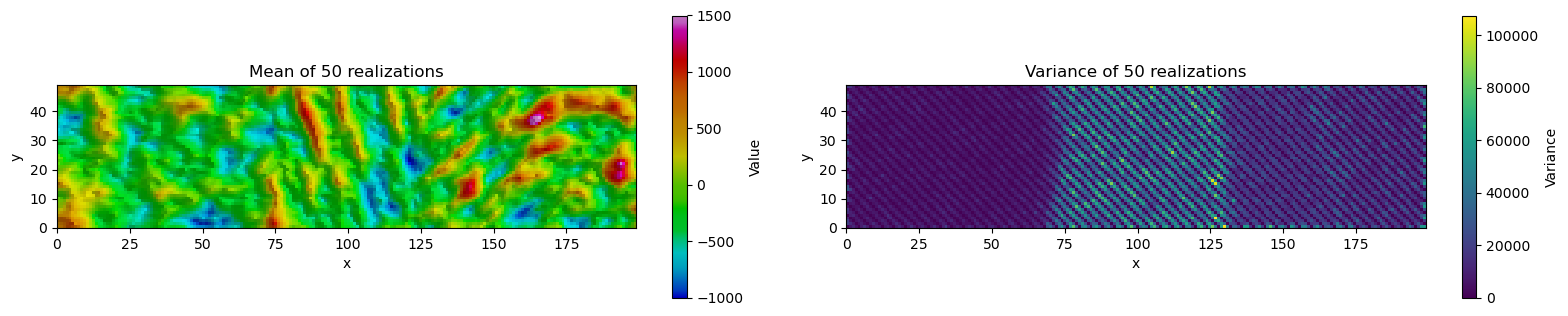

Mean field: min=-990.3, max=1782.8
Variance field: min=0.0, max=107587.3
NaN count in mean: 0


In [42]:
## PLOT MEAN AND VARIANCE OF 50 REALIZATIONS ##
## ========================================= ##

from matplotlib.colors import Normalize

# color scale limits for mean (same as single realization):
vmin, vmax = -1000, 1500
norm = Normalize(vmin=vmin, vmax=vmax)

# get grid dimensions from the last df_mgsim:
x_coords = df_mgsim['x'].values
y_coords = df_mgsim['y'].values
x_unique = np.unique(x_coords)
y_unique = np.unique(y_coords)
nx, ny = len(x_unique), len(y_unique)
extent = [x_unique.min(), x_unique.max(), y_unique.min(), y_unique.max()]

# reshape mean and variance to 2D grids:
mean_grid = mean_field.reshape(ny, nx)
var_grid = var_field.reshape(ny, nx)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean field with light-shading
ax1 = axes[0]
mean_rgb = ls.shade(mean_grid, cmap=geosoft_cmap, blend_mode='soft', vmin=vmin, vmax=vmax)
ax1.imshow(mean_rgb, origin='lower', extent=extent, interpolation='nearest')
ax1.set_title('Mean of 50 realizations')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
sm1 = plt.cm.ScalarMappable(norm=norm, cmap=geosoft_cmap)
sm1.set_array([])
fig.colorbar(sm1, ax=ax1, shrink=0.6, label='Value')

# Variance field
ax2 = axes[1]
im2 = ax2.imshow(var_grid, origin='lower', extent=extent, cmap='viridis', interpolation='nearest')
ax2.set_title('Variance of 50 realizations')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
fig.colorbar(im2, ax=ax2, shrink=0.6, label='Variance')

plt.tight_layout()
plt.show()

# Print stats to check for NaN issues
print(f"Mean field: min={np.nanmin(mean_field):.1f}, max={np.nanmax(mean_field):.1f}")
print(f"Variance field: min={np.nanmin(var_field):.1f}, max={np.nanmax(var_field):.1f}")
print(f"NaN count in mean: {np.isnan(mean_field).sum()}")


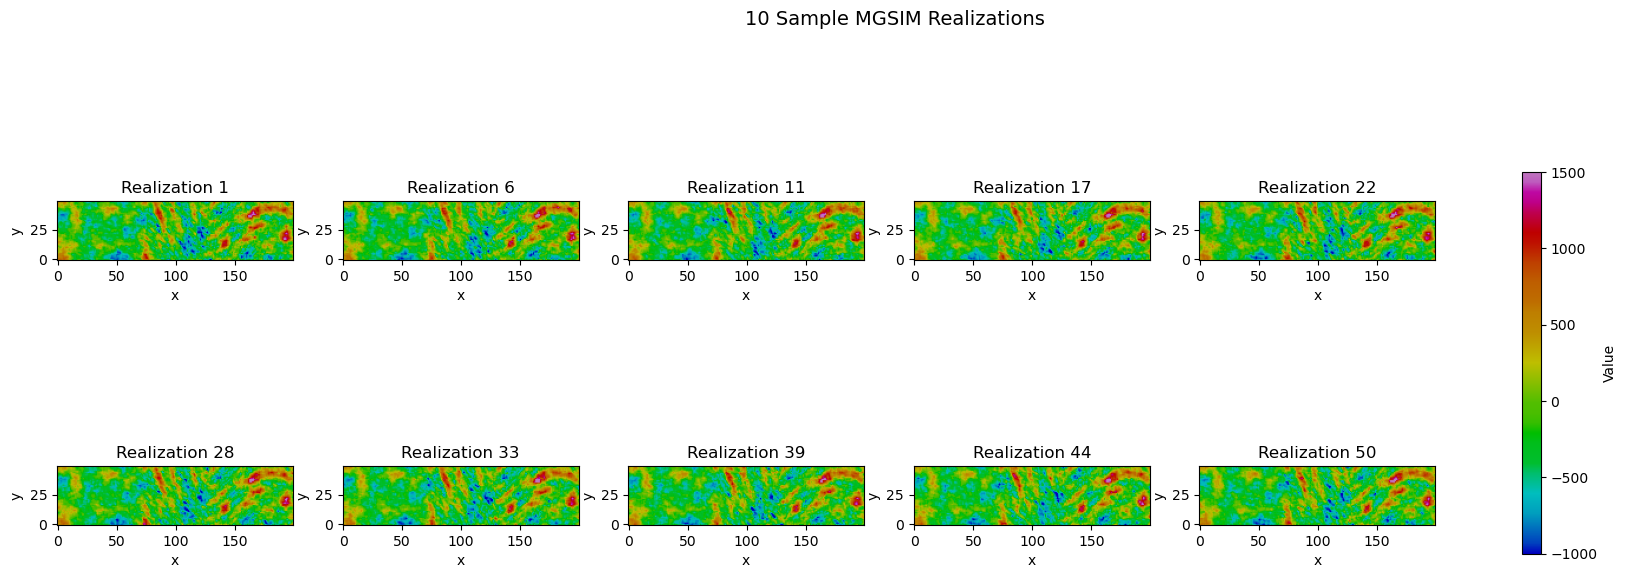

In [44]:
## PLOT 10 SAMPLE REALIZATIONS ##
## =========================== ##

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

nx = df_xyvtcs['x'].nunique()
ny = df_xyvtcs['y'].nunique()

# Fixed color scale (same as single realization)
vmin, vmax = -1000, 1500

# Pick 10 evenly spaced realizations
indices = np.linspace(0, n_realizations-1, 10, dtype=int)

for i, idx in enumerate(indices):
    ax = axes[i]
    im = ax.imshow(realizations[idx].reshape(ny, nx), origin='lower', cmap=geosoft_cmap, 
                   aspect='equal', vmin=vmin, vmax=vmax)
    ax.set_title(f'Realization {idx+1}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('10 Sample MGSIM Realizations', fontsize=14)
plt.tight_layout()
fig.colorbar(im, ax=axes, shrink=0.6, label='Value')
plt.show()
